In [22]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import os

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [23]:
plots_dir = "plots"
os.makedirs(plots_dir, exist_ok=True)

In [4]:
metrics_df = pd.read_csv("training_metrics.csv")
metrics_df.head()

,epoch,train_loss,val_loss,train_acc,val_acc
0,1,1.182677,0.889620,52.540241,64.577398
1,2,0.881611,0.779890,66.742119,69.753086
2,3,0.757948,0.648797,72.702884,76.210826
3,4,0.683645,0.658013,75.880282,74.738841
4,5,0.630082,0.558753,78.395372,81.101614


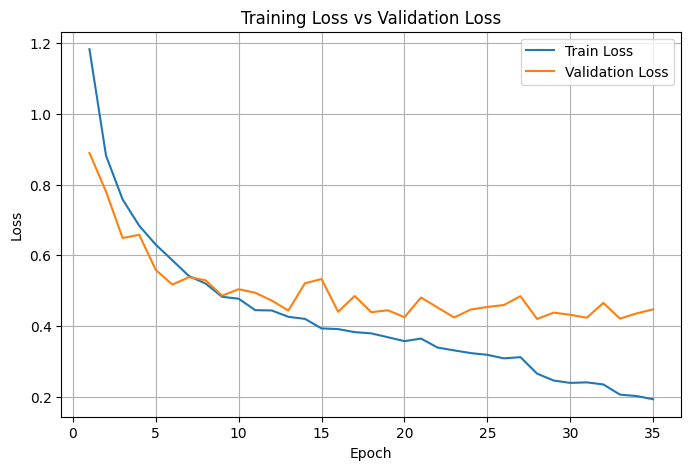

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(metrics_df["epoch"], metrics_df["train_loss"], label="Train Loss")
plt.plot(metrics_df["epoch"], metrics_df["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(plots_dir, "loss_plot.png"), dpi=300, bbox_inches="tight")
plt.show()

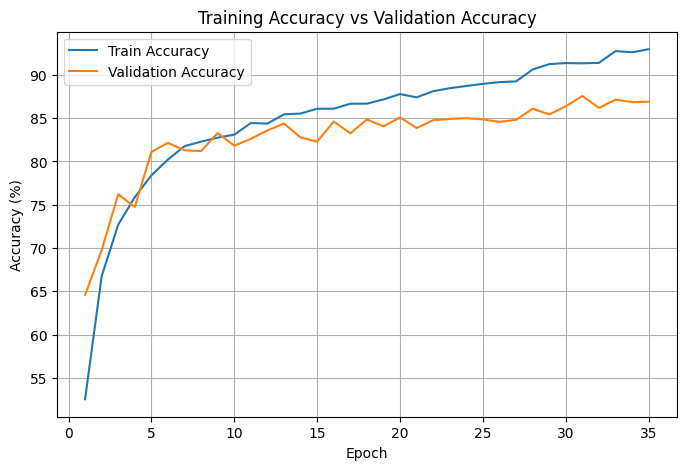

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(metrics_df["epoch"], metrics_df["train_acc"], label="Train Accuracy")
plt.plot(metrics_df["epoch"], metrics_df["val_acc"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(plots_dir, "accuracy_plot.png"), dpi=300, bbox_inches="tight")
plt.show()

In [7]:
best_loss_idx = metrics_df["val_loss"].idxmin()
best_loss_epoch = metrics_df.loc[best_loss_idx, "epoch"]
best_val_loss = metrics_df.loc[best_loss_idx, "val_loss"]
best_val_acc_at_loss = metrics_df.loc[best_loss_idx, "val_acc"]

print("Best Validation Loss Model")
print(f"Epoch: {best_loss_epoch}")
print(f"Validation Loss: {best_val_loss:.4f}")
print(f"Validation Accuracy: {best_val_acc_at_loss:.2f}%")

Best Validation Loss Model
Epoch: 28
Validation Loss: 0.4200
Validation Accuracy: 86.09%


In [8]:
best_acc_idx = metrics_df["val_acc"].idxmax()
best_acc_epoch = metrics_df.loc[best_acc_idx, "epoch"]
best_val_acc = metrics_df.loc[best_acc_idx, "val_acc"]
val_loss_at_best_acc = metrics_df.loc[best_acc_idx, "val_loss"]

print("Best Validation Accuracy Model")
print(f"Epoch: {best_acc_epoch}")
print(f"Validation Accuracy: {best_val_acc:.2f}%")
print(f"Validation Loss: {val_loss_at_best_acc:.4f}")

Best Validation Accuracy Model
Epoch: 31
Validation Accuracy: 87.56%
Validation Loss: 0.4235


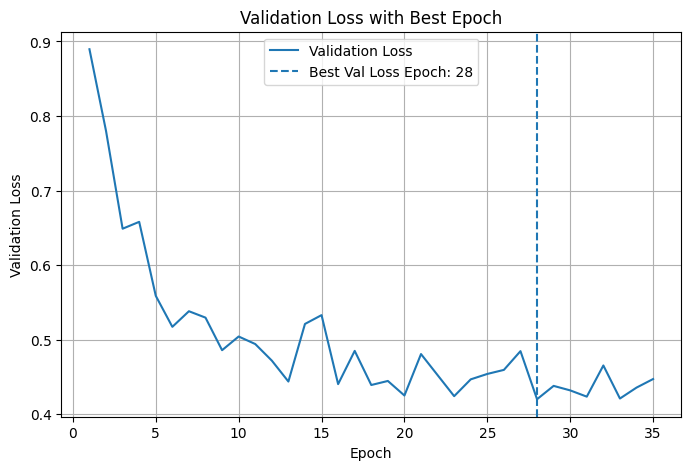

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(metrics_df["epoch"], metrics_df["val_loss"], label="Validation Loss")
plt.axvline(best_loss_epoch, linestyle="--", label=f"Best Val Loss Epoch: {int(best_loss_epoch)}")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss with Best Epoch")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(plots_dir, "best_val_loss_plot.png"), dpi=300, bbox_inches="tight")

plt.show()

In [10]:
val_test_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [11]:
test_dir = "data/seg_test/"

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=val_test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

class_names = test_dataset.classes
print(class_names)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [12]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(18*18*128, 256), 
            nn.ReLU(), 
            nn.Dropout(0.5), 
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 6)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

In [14]:
model = CNN().to(device)
state_dict = torch.load("best_model.pt", map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


In [17]:
criterion = nn.CrossEntropyLoss()

test_loss = 0.0
correct_test = 0
total_test = 0

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        correct_test += (predicted == labels).sum().item()
        total_test += labels.size(0)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss = test_loss / len(test_loader)
test_acc = 100 * correct_test / total_test

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

Test Loss: 0.3987
Test Accuracy: 87.20%


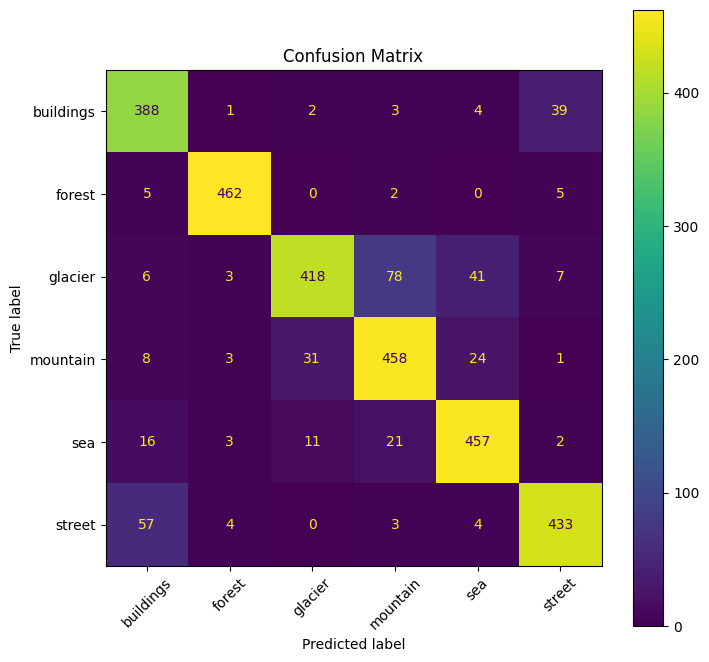

In [27]:
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45)

plt.title("Confusion Matrix")
plt.savefig(os.path.join(plots_dir, "confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

In [20]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names
))

              precision    recall  f1-score   support

   buildings       0.81      0.89      0.85       437
      forest       0.97      0.97      0.97       474
     glacier       0.90      0.76      0.82       553
    mountain       0.81      0.87      0.84       525
         sea       0.86      0.90      0.88       510
      street       0.89      0.86      0.88       501

    accuracy                           0.87      3000
   macro avg       0.87      0.88      0.87      3000
weighted avg       0.87      0.87      0.87      3000

